In [4]:
import torch, cebra, os
import numpy as np
from cebra.data.datasets import TensorDataset
import re
import numpy as np
import torch
from cebra.data import TensorDataset 
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.ndimage import gaussian_filter1d

### SET BASE_DIR ###
BASE_DIR = '/mnt/moritz'

# ---------- Helpers ----------
def normalize_sub_id(s: str) -> str:
    """Strip whitespace, drop trailing T1/T2 for GC/GS IDs; leave others as-is."""
    s = str(s).strip()
    su = s.upper()
    if su.startswith(("GC", "GS")) and re.search(r"T[12]$", su):
        return s[:-2]
    return s

def sessions_to_int(arr) -> np.ndarray:
    """Map sessions to ints; supports 'T1'/'T2', numeric strings, or numeric arrays."""
    a = np.asarray(arr)
    if a.dtype.kind in "iuf":
        return a.astype(np.int64)
    s = np.char.upper(a.astype(str))
    out = np.full(s.shape, -1, dtype=np.int64)
    t2 = np.char.endswith(s, "T2")
    t1 = np.char.endswith(s, "T1")
    out[t2] = 2
    out[t1] = 1
    rem = ~(t1 | t2)
    if np.any(rem):
        try:
            out[rem] = s[rem].astype(np.int64, copy=False)
        except Exception:
            pass
    return out

def encode_subjects_joint(*label_arrays: np.ndarray) -> tuple[list[np.ndarray], np.ndarray]:
    """
    Jointly integer-encode multiple subject label arrays so their codes are consistent across datasets.
    Returns the list of encoded arrays (int64) and the 'classes_' (unique strings).
    """
    labs = [np.asarray(x).astype(str) for x in label_arrays]
    # normalize IDs first
    labs_norm = [np.array([normalize_sub_id(u) for u in arr], dtype=object) for arr in labs]
    # stack to compute a single mapping
    all_concat = np.concatenate(labs_norm, axis=0).astype(str)
    classes, inv_all = np.unique(all_concat, return_inverse=True)
    # split back
    split_points = np.cumsum([len(a) for a in labs_norm[:-1]])
    inv_split = np.split(inv_all, split_points)
    enc = [x.astype(np.int64) for x in inv_split]
    return enc, classes

In [5]:
# ---------- Load dataset 1 in-house dataset ----------
path1 = os.path.join(BASE_DIR, 'CEBRA_project/data/Geneva_Schizophrenia_Begue/all_subjects_concat_fMRI_harvardoxford_timeseries.npz')
meta_data_path1 = os.path.join(BASE_DIR, 'CEBRA_project/data/Geneva_Schizophrenia_Begue/final_metadata.xlsx')
neural1 = np.load(path1, allow_pickle=True)['timeseries'].astype(np.float32)
session1 = np.load(path1, allow_pickle=True)['session_id']


with np.load(path1, allow_pickle=True) as f:
    subj1 = f['sub_id']      # strings


# Load the .xlsx file using pandas
meta_data_df1 = pd.read_excel(meta_data_path1)

# Ensure that both sub_id columns are strings (or both numerical if needed)
meta_data_df1['sub_id'] = meta_data_df1['sub_id'].astype(str)  # Convert meta_data's sub_id to string

# Function to standardize subject IDs
def standardize_subj_id(subj_id):
    # Remove leading zeros
    subj_id = subj_id.lstrip("0")
    if subj_id.endswith("T1") or subj_id.endswith("T2"):
        subj_id = subj_id[:-2]
    return subj_id

# Standardize subj1
subj1_standardized = np.array([standardize_subj_id(subj) for subj in subj1])


# Create a DataFrame with sub_id and session from the .npz data
npz_data_df1 = pd.DataFrame({
    'sub_id': subj1_standardized,  # Use the standardized subject IDs
    'session': session1,
})
npz_data_df1['neural'] = [arr.astype(np.float32) for arr in neural1]

# Merge the data based on 'sub_id' and 'session' 
merged_df1 = pd.merge(npz_data_df1, meta_data_df1, 
                     left_on=['sub_id', 'session'], right_on=['sub_id', 'session'], how='left')

merged_df1["group"] = merged_df1["group"].map({
    "Schizophrenia": 0,
    "Healthy Control": 1
})


# ---------- Load dataset 2 HCP-EP ----------
path2 = os.path.join(BASE_DIR, 'CEBRA_project/data/HCP-EP/all_subjects_concat_fMRI_harvardoxford_timeseries.npz')
meta_data_path2 = os.path.join(BASE_DIR, 'CEBRA_project/data/HCP-EP/final_metadata.xlsx')
neural2 = np.load(path2, allow_pickle=True)['timeseries'].astype(np.float32)
session2 = np.load(path2, allow_pickle=True)['session_id']
with np.load(path2, allow_pickle=True) as f:
    subj2 = f['sub_id']      # currently ints



# Make sides strings
meta_data_df2 = pd.read_excel(meta_data_path2)
meta_data_df2['sub_id'] = meta_data_df2['sub_id'].astype(str)



# Convert before creating the DataFrame
subj2 = subj2.astype(str)

npz_data_df2 = pd.DataFrame({
    'sub_id': subj2,
    'session': session2,
})
npz_data_df2['neural'] = [arr.astype(np.float32) for arr in neural2]

merged_df2 = pd.merge(
    npz_data_df2,
    meta_data_df2,
    left_on=['sub_id'],
    right_on=['sub_id'],
    how='left'
)

merged_df2["group"] = merged_df2["group"].map({
    "Non-affective psychosis": 0,
    "Affective psychosis": 0,
    "In good health": 1
})

merged_df2['ds_type'] = 2
merged_df1['ds_type'] = 1

combined = pd.concat([merged_df1, merged_df2], axis=0, ignore_index=True)
print(combined.columns)

cols_to_nan = [
    "panss_negative",
    "panss_negative_EPA",
    "panss_apathy_Indrit",
    "panss_positive",
]

combined.loc[combined["sub_id"] == "4015", cols_to_nan] = np.nan # Did not complete PANSS assessment

Index(['sub_id', 'session', 'neural', 'risperidon_score', 'bacs_total',
       'bacs_att', 'panss_positive', 'panss_negative', 'panss_negative_EPA',
       'panss_apathy_Indrit', 'age_years', 'sex', 'bnss_apathy', 'group',
       'ds_type', 'CAINS_MAP', 'fluid_cognition_score',
       'crystal_cognition_score', 'total_cognition_score',
       'lifetime_antipsychotic_drug', 'CPZ_score', 'money_delay_auc_200',
       'money_delay_auc_40000', 'pattern_processing_speed_NIH',
       'grip_strength_age_unadjusted', 'panss_general', 'interview_age'],
      dtype='object')


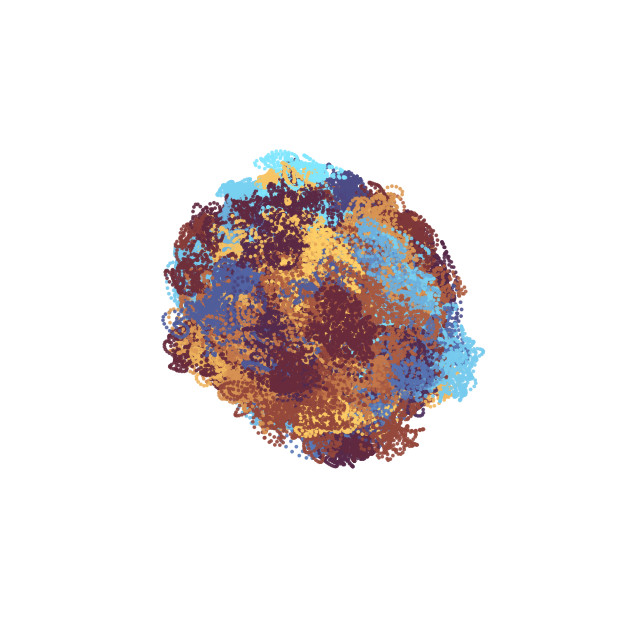

In [ ]:
# ==========================================
# 1. DATA LOADING
# ==========================================
# Path to embedding
npz_path = os.path.join(BASE_DIR, 'CEBRA_project/Scripts_to_publish/xCEBRA_models_to_publish/ensembled_embeddings/regularizer_weight_10p0/ensemble_avg_weight10p0.npz')

# Load the combined average embeddings
z = np.load(npz_path, mmap_mode="r", allow_pickle=False)
combined_avg = np.array(z["combined_avg"], copy=True) # shape: (N, D), dtype float32

# Isolate the first 3 dimensions for 3D plotting
embedding_3d = combined_avg[:, :3]


# Extract the subject IDs array
sub_all = combined["sub_id"].values 
unique_subjects = np.unique(sub_all)


unique_labels = {label: i for i, label in enumerate(unique_subjects)}
label_values = np.array([unique_labels[label] for label in sub_all])


# ==========================================
# 3. BOUNDARY-AWARE SMOOTHING
# ==========================================
sigma = 3.0 
smoothed_embedding = np.zeros_like(embedding_3d)

for subj in unique_subjects:
    mask = (sub_all == subj)
    smoothed_embedding[mask] = gaussian_filter1d(embedding_3d[mask], sigma=sigma, axis=0)


# ==========================================
# 4. COLORMAP & PLOT SETUP
# ==========================================
# Enable dark background style
plt.style.use('dark_background')

# Create a discrete, shuffled version of the RAINBOW colormap
rainbow_continuous = plt.get_cmap('rainbow')
colors = rainbow_continuous(np.linspace(0, 1, len(unique_subjects)))

rng = np.random.default_rng(42) 
rng.shuffle(colors)
discrete_rainbow_shuffled = ListedColormap(colors)

# Initialize figure with a transparent background
fig = plt.figure(figsize=(10, 8), facecolor='none')
ax = fig.add_subplot(111, projection="3d")

# ==========================================
# 5. PLOTTING
# ==========================================
# Plot the embedding
ax = cebra.plot_embedding(
    embedding=smoothed_embedding,
    embedding_labels=label_values, 
    cmap='managua',  
    markersize=3,
    alpha=0.8,
    ax=ax,
)


# ==========================================
# 6. CLEANUP & SAVE
# ==========================================
# Completely hide the axes, ticks, and background panes
ax.set_axis_off()

# Force transparency on the figure and axes patches
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

# Handle 3D background panes transparency explicitly
if hasattr(ax, 'xaxis'):
    ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    # Turn off grid explicitly
    ax.grid(False)

# Save the plot with transparency
plt.savefig(os.path.join(BASE_DIR, 'CEBRA_project/Scripts_to_publish/Plotting_for_figures/Figure_2/embedding_plot.png'), transparent=True, bbox_inches='tight', dpi = 300)

# Show the plot
plt.show()